# Dijkstra's Algorithm: Geodesic Distances and Paths

Dijkstra's algorithm (1959) solves the **single-source shortest path** problem on a weighted graph $G = (V, E, w)$ with non-negative edge weights $w : E \to \mathbb{R}_{\geq 0}$. Starting from a source node $s \in V$, it computes the geodesic distance
$$
d(s, v) = \min_{\text{paths } s \leadsto v} \sum_{e \in \text{path}} w(e)
$$
for every vertex $v \in V$, together with a **parent pointer** $\pi(v)$ recording the predecessor of $v$ on the optimal path. The **geodesic path** from $s$ to any target $t$ is then recovered by backtracking:
$$
t \to \pi(t) \to \pi(\pi(t)) \to \cdots \to s.
$$

## Core idea: greedy relaxation via a priority queue

Dijkstra maintains a **tentative distance** $\tilde{d}(v)$, initialized to $0$ at the source and $+\infty$ elsewhere. At each step it extracts the unvisited vertex $u$ with smallest $\tilde{d}(u)$ (via a min-heap) and **relaxes** each outgoing edge $(u, v)$:
$$
\tilde{d}(v) \leftarrow \min\!\bigl(\tilde{d}(v),\; \tilde{d}(u) + w(u,v)\bigr).
$$
Because all weights are non-negative, once a vertex is extracted it holds its true shortest distance. The algorithm terminates in $O((|V|+|E|)\log|V|)$ time with a binary heap.

## Grid graphs

On a regular $n \times n$ grid with 4-connectivity, each node $(i,j)$ has up to four neighbours. The **cost to enter cell $(i,j)$** is $w[i,j]$, and the weight of edge $(i,j) \to (i',j')$ is taken as the average $\frac{1}{2}(w[i,j]+w[i',j'])$. This setup discretises the **eikonal equation** governing geodesic distances in a Riemannian metric $w$:
$$
\|\nabla d\|_w = 1, \qquad d(s) = 0.
$$
Dijkstra on a weighted grid thus acts as a first-order solver for front propagation problems.

This notebook demonstrates:
1. A **small hand-crafted graph** with visible node labels and highlighted shortest path.
2. A **120×120 weighted grid** with a slow region (obstacle), showing the cost map, distance map, and extracted geodesic.
3. A **maze example** with walls (infinite-cost cells) where the path winds through corridors.
4. An **interactive slider** to explore how the source position changes the distance map on the grid.

## Setup

We implement Dijkstra once with **parent tracking**, usable both for general graphs (adjacency list) and grid graphs.

In [1]:
from pathlib import Path
import heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False

OUT = Path(".")

## Dijkstra on an adjacency list

The priority queue always extracts the unsettled vertex with smallest tentative distance. Relaxing an edge $(u,v)$ applies
$$d(v)\leftarrow\min\{d(v),d(u)+w_{uv}\}.

In [2]:
# ── General graph Dijkstra (adjacency list) ─────────────────────────────────
def dijkstra_graph(adj, src):
    """Dijkstra on a weighted graph given as adjacency list.
    adj[u] = list of (v, weight) pairs.
    Returns dist dict and parent dict.
    """
    dist = {u: np.inf for u in adj}
    parent = {u: None for u in adj}
    dist[src] = 0.0
    pq = [(0.0, src)]
    visited = set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, v))
    return dist, parent


def get_path_graph(parent, src, dst):
    """Reconstruct path from parent dict."""
    path = []
    cur = dst
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    if path[0] != src:
        return []  # no path
    return path

## Weighted grid specialization

A four-neighbor grid is a graph whose edge cost is the average cost of adjacent cells. Parent pointers retain the minimizing discrete geodesic.

In [3]:
# ── Grid Dijkstra (4-connectivity, weight = cost to enter cell) ─────────────
def dijkstra_grid(w, src):
    """Dijkstra on an n×n grid with weight array w.
    Returns distance array dist and parent array par (shape n×n×2).
    Cells with w = inf act as walls.
    """
    n, m = w.shape
    dist = np.full((n, m), np.inf)
    par  = np.full((n, m, 2), -1, dtype=int)
    visited = np.zeros((n, m), dtype=bool)
    si, sj = src
    dist[si, sj] = 0.0
    pq = [(0.0, si, sj)]
    while pq:
        d, i, j = heapq.heappop(pq)
        if visited[i, j]:
            continue
        visited[i, j] = True
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ii, jj = i + di, j + dj
            if 0 <= ii < n and 0 <= jj < m and not visited[ii, jj]:
                edge_w = 0.5 * (w[i, j] + w[ii, jj])
                nd = d + edge_w
                if nd < dist[ii, jj]:
                    dist[ii, jj] = nd
                    par[ii, jj] = [i, j]
                    heapq.heappush(pq, (nd, ii, jj))
    return dist, par


def get_path_grid(par, src, dst):
    """Backtrack parent pointers to extract geodesic on grid."""
    path = []
    cur = dst
    while cur != src:
        path.append(cur)
        p = tuple(par[cur])
        if p == (-1, -1):
            return np.array([])  # unreachable
        cur = p
    path.append(src)
    return np.array(path[::-1])


print("Dijkstra implementations ready.")

Dijkstra implementations ready.


## Simple Example: Small Weighted Graph

We build a small hand-crafted weighted graph on 10 nodes. Every edge carries an explicit positive weight. Dijkstra is run from node $s=0$ and the shortest path to each target $t$ is highlighted.

For a graph with $n$ nodes and $m$ edges, the priority-queue implementation runs in
$$
O((n + m) \log n)
$$
time. On this tiny graph the result is immediate, but the same code scales to millions of nodes.

In [4]:
# Hand-crafted graph: 10 nodes, undirected, with positive weights
nodes = list(range(10))
edges = [
    (0, 1, 4), (0, 2, 1), (1, 3, 1), (1, 4, 5),
    (2, 1, 2), (2, 5, 8), (3, 4, 3), (3, 6, 2),
    (4, 7, 2), (5, 8, 1), (6, 7, 1), (6, 9, 4),
    (7, 9, 3), (8, 9, 7),
]

# Build adjacency list (undirected)
adj = {u: [] for u in nodes}
for u, v, w in edges:
    adj[u].append((v, float(w)))
    adj[v].append((u, float(w)))

# Fixed positions for clean visualisation
pos = {
    0: (0.0, 0.5),
    1: (1.0, 1.0),
    2: (1.0, 0.0),
    3: (2.0, 1.2),
    4: (2.5, 0.8),
    5: (2.0, -0.4),
    6: (3.2, 1.4),
    7: (3.5, 0.6),
    8: (3.0, -0.4),
    9: (4.5, 0.8),
}

SRC = 0
dist_g, parent_g = dijkstra_graph(adj, SRC)

## Read several shortest paths

Using one source solve, we reconstruct paths to three targets and highlight both cumulative distance labels and the selected predecessor chain.

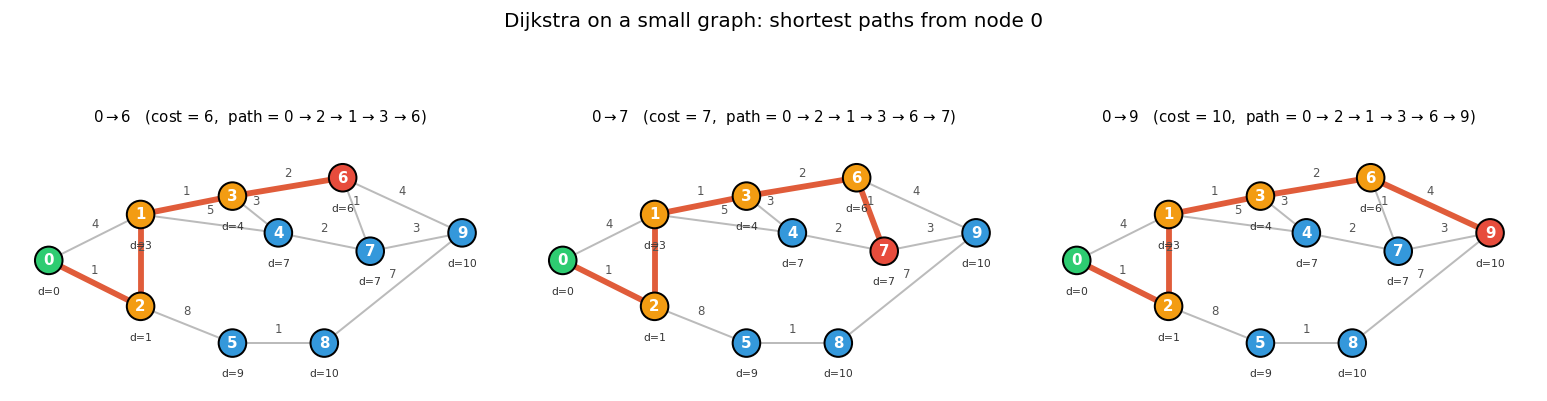

In [5]:
# Show three target paths side by side
targets = [6, 7, 9]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, tgt in zip(axes, targets):
    path = get_path_graph(parent_g, SRC, tgt)
    path_edges = set(zip(path[:-1], path[1:]))

    # Draw all edges
    for u, v, w in edges:
        xu, yu = pos[u]
        xv, yv = pos[v]
        on_path = (u, v) in path_edges or (v, u) in path_edges
        color = "#e05c3a" if on_path else "#bbbbbb"
        lw    = 3.5       if on_path else 1.2
        ax.plot([xu, xv], [yu, yv], color=color, lw=lw, zorder=1)
        mx, my = (xu + xv) / 2, (yu + yv) / 2
        ax.text(mx, my + 0.08, str(w), ha="center", va="bottom",
                fontsize=7, color="#555555")

    # Draw nodes
    for u in nodes:
        xu, yu = pos[u]
        if u == SRC:
            fc = "#2ecc71"
        elif u == tgt:
            fc = "#e74c3c"
        elif u in path:
            fc = "#f39c12"
        else:
            fc = "#3498db"
        circ = plt.Circle((xu, yu), 0.15, fc=fc, ec="k", lw=1.2, zorder=3)
        ax.add_patch(circ)
        ax.text(xu, yu, str(u), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white", zorder=4)
        # distance label
        ax.text(xu, yu - 0.28, f"d={dist_g[u]:.0f}",
                ha="center", va="top", fontsize=6.5, color="#333333")

    ax.set_xlim(-0.4, 5.0)
    ax.set_ylim(-0.9, 1.9)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"$0 \\to {tgt}$   (cost = {dist_g[tgt]:.0f},  path = {' → '.join(map(str, path))})",
        fontsize=9
    )

fig.suptitle("Dijkstra on a small graph: shortest paths from node 0", fontsize=12)
plt.tight_layout()

## Weighted Grid and Geodesic Path

We now move to a $120 \times 120$ grid. Each cell $(i,j)$ carries a positive **speed** (or inverse cost) $w[i,j] \geq 1$. Two Gaussian bumps create **slow regions** — areas where moving is expensive. The weight of the edge connecting cells $(i,j)$ and $(i',j')$ is
$$
w_{\text{edge}} = \tfrac{1}{2}\bigl(w[i,j] + w[i',j']\bigr),
$$
the arithmetic mean of the endpoint costs. This is the simplest symmetric discretisation of the continuous travel-time integral.

Dijkstra is run from the **top-left corner** $(0,0)$ to the **bottom-right** $(n-1, n-1)$. We display:
- the weight (cost) map,
- the distance map, and
- the extracted geodesic path overlaid on both.

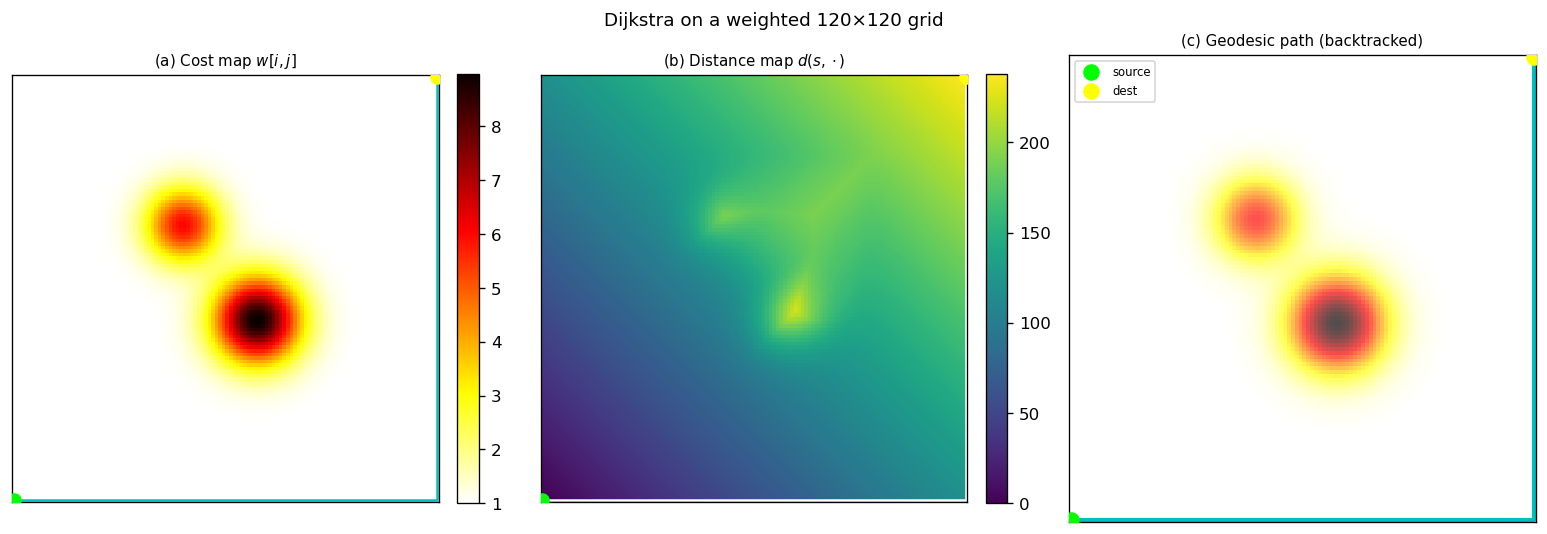

In [6]:
n = 120
x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

# Smooth obstacle: two Gaussian bumps making certain regions slow
w_grid = (1.0
          + 8.0 * np.exp(-((X - 0.15)**2 + (Y + 0.15)**2) / 0.04)
          + 5.0 * np.exp(-((X + 0.20)**2 + (Y - 0.30)**2) / 0.03))

src_grid = (0, 0)
dst_grid = (n - 1, n - 1)

dist_grid, par_grid = dijkstra_grid(w_grid, src_grid)
path_grid = get_path_grid(par_grid, src_grid, dst_grid)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# (a) Cost/weight map
ax = axes[0]
im = ax.imshow(w_grid, origin="lower", cmap="hot_r", aspect="equal")
if len(path_grid) > 0:
    ax.plot(path_grid[:, 1], path_grid[:, 0], "c-", lw=1.5, label="geodesic")
ax.scatter([src_grid[1]], [src_grid[0]], c="lime",   s=60, zorder=5)
ax.scatter([dst_grid[1]], [dst_grid[0]], c="yellow", s=60, zorder=5)
ax.set_title("(a) Cost map $w[i,j]$", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (b) Distance map
ax = axes[1]
im2 = ax.imshow(dist_grid, origin="lower", cmap="viridis", aspect="equal")
if len(path_grid) > 0:
    ax.plot(path_grid[:, 1], path_grid[:, 0], "w-", lw=1.5, label="geodesic")
ax.scatter([src_grid[1]], [src_grid[0]], c="lime",   s=60, zorder=5)
ax.scatter([dst_grid[1]], [dst_grid[0]], c="yellow", s=60, zorder=5)
ax.set_title(r"(b) Distance map $d(s, \cdot)$", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (c) Geodesic path on cost map
ax = axes[2]
ax.imshow(w_grid, origin="lower", cmap="hot_r", aspect="equal", alpha=0.7)
if len(path_grid) > 0:
    ax.plot(path_grid[:, 1], path_grid[:, 0], "c-", lw=2.5)
ax.scatter([src_grid[1]], [src_grid[0]], c="lime",   s=80, zorder=5, label="source")
ax.scatter([dst_grid[1]], [dst_grid[0]], c="yellow", s=80, zorder=5, label="dest")
ax.legend(fontsize=7, loc="upper left")
ax.set_title("(c) Geodesic path (backtracked)", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Dijkstra on a weighted 120×120 grid", fontsize=11)
plt.tight_layout()

## Maze Example

Mazes are extreme weighted grids: cells are either **free** (cost 1) or **walls** (cost $+\infty$). Dijkstra degenerates to breadth-first search in the free region and naturally finds the **shortest corridor path**.

We generate the maze using a **recursive subdivision** strategy that places horizontal and vertical wall segments with a single gap each, then repeats recursively. This guarantees the maze is connected (solvable) while producing winding corridors:
$$
\text{maze}[i,j] = \begin{cases} +\infty & \text{if cell is a wall,} \\ 1 & \text{if cell is free.} \end{cases}
$$
The geodesic path must navigate around every wall, producing a visually interesting trajectory.

In [7]:
def build_maze(n, seed=7):
    """Build an n×n binary maze (0=free, 1=wall) via recursive subdivision.
    The border is always free; a gap ensures connectivity.
    """
    rng = np.random.default_rng(seed)
    grid = np.zeros((n, n), dtype=int)  # 0 = free

    def subdivide(r0, c0, r1, c1):
        """Recursively add walls inside rectangle [r0..r1] x [c0..c1]."""
        height = r1 - r0
        width  = c1 - c0
        if height < 3 or width < 3:
            return
        # Choose orientation: prefer to divide the longer dimension
        if height > width:
            horizontal = True
        elif width > height:
            horizontal = False
        else:
            horizontal = rng.integers(0, 2) == 0

        if horizontal:
            # Horizontal wall at an even row
            candidates = [r for r in range(r0 + 2, r1 - 1, 2)]
            if not candidates:
                return
            wall_row = rng.choice(candidates)
            gap_col  = rng.integers(c0, c1 + 1)
            for c in range(c0, c1 + 1):
                if c != gap_col:
                    grid[wall_row, c] = 1
            subdivide(r0, c0, wall_row - 1, c1)
            subdivide(wall_row + 1, c0, r1, c1)
        else:
            # Vertical wall at an even column
            candidates = [c for c in range(c0 + 2, c1 - 1, 2)]
            if not candidates:
                return
            wall_col = rng.choice(candidates)
            gap_row  = rng.integers(r0, r1 + 1)
            for r in range(r0, r1 + 1):
                if r != gap_row:
                    grid[r, wall_col] = 1
            subdivide(r0, c0, r1, wall_col - 1)
            subdivide(r0, wall_col + 1, r1, c1)

    subdivide(0, 0, n - 1, n - 1)
    return grid

## Solve on a recursive maze

Walls receive infinite cost, so Dijkstra explores only the free subgraph and parent pointers encode a winding feasible route.

In [8]:
nm = 61  # odd size works nicely with subdivision
maze_binary = build_maze(nm, seed=42)

# Convert to weight array: free=1, wall=inf
w_maze = np.where(maze_binary == 1, np.inf, 1.0)

# Ensure source/dest are free
w_maze[0, 0] = 1.0
w_maze[nm - 1, nm - 1] = 1.0

src_maze = (0, 0)
dst_maze = (nm - 1, nm - 1)

dist_maze, par_maze = dijkstra_grid(w_maze, src_maze)
path_maze = get_path_grid(par_maze, src_maze, dst_maze)

## Maze distance and geodesic

The distance map displays the full value function, while the overlaid path is one minimizing backtrack from destination to source.

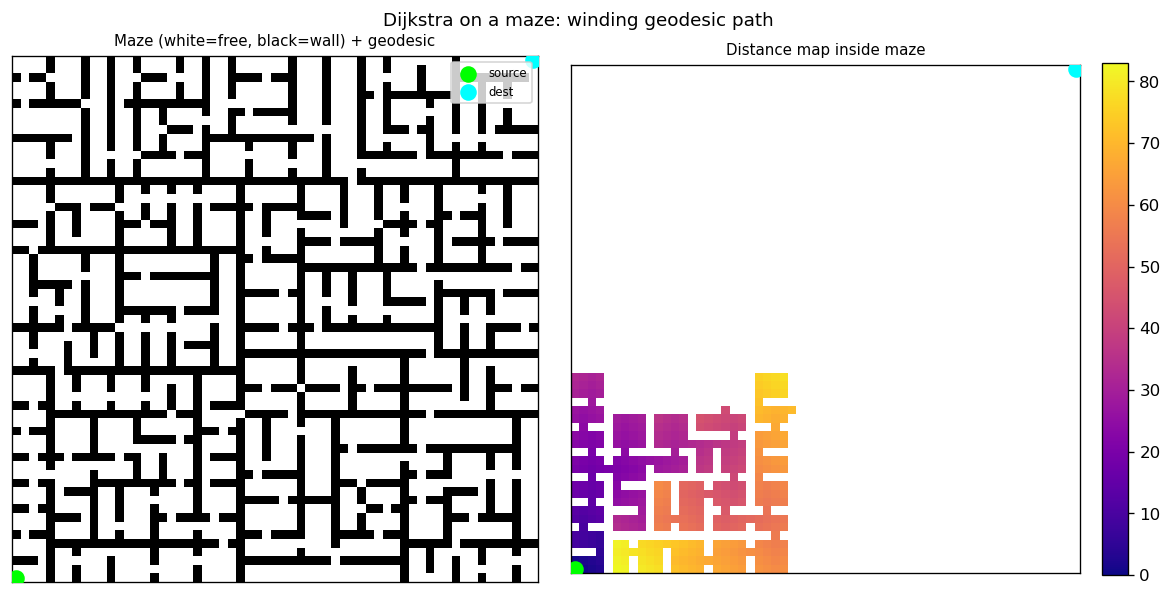

In [9]:
# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Maze structure
ax = axes[0]
ax.imshow(maze_binary, origin="lower", cmap="binary", aspect="equal",
          interpolation="nearest")
if len(path_maze) > 0:
    ax.plot(path_maze[:, 1], path_maze[:, 0], "r-", lw=1.5, label="geodesic")
ax.scatter([src_maze[1]], [src_maze[0]], c="lime",   s=80, zorder=5, label="source")
ax.scatter([dst_maze[1]], [dst_maze[0]], c="cyan",   s=80, zorder=5, label="dest")
ax.legend(fontsize=7, loc="upper right")
ax.set_title("Maze (white=free, black=wall) + geodesic", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

# Distance map inside the maze
ax = axes[1]
d_vis = np.where(np.isinf(dist_maze), np.nan, dist_maze)
im = ax.imshow(d_vis, origin="lower", cmap="plasma", aspect="equal",
               interpolation="nearest")
# Overlay walls in grey
wall_mask = np.ma.masked_where(maze_binary == 0, maze_binary).astype(float)
ax.imshow(wall_mask, origin="lower", cmap="Greys", aspect="equal",
          interpolation="nearest", alpha=0.6)
if len(path_maze) > 0:
    ax.plot(path_maze[:, 1], path_maze[:, 0], "w-", lw=1.5)
ax.scatter([src_maze[1]], [src_maze[0]], c="lime",  s=80, zorder=5)
ax.scatter([dst_maze[1]], [dst_maze[0]], c="cyan",  s=80, zorder=5)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Distance map inside maze", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Dijkstra on a maze: winding geodesic path", fontsize=11)
plt.tight_layout()

## Interactive: Source Position on the Weighted Grid

Move the **source** across the grid (row and column sliders) to see how both the **distance map** and the **geodesic to the bottom-right corner** change in real time. The wavefronts of equal distance (level sets of $d(s,\cdot)$) bend around the slow regions, illustrating the Riemannian nature of the metric.

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

n_int = 80  # smaller grid for interactive speed
xi = np.linspace(-1, 1, n_int)
yi = np.linspace(-1, 1, n_int)
Xi, Yi = np.meshgrid(xi, yi)
w_int = (1.0
         + 8.0 * np.exp(-((Xi - 0.15)**2 + (Yi + 0.15)**2) / 0.04)
         + 5.0 * np.exp(-((Xi + 0.20)**2 + (Yi - 0.30)**2) / 0.03))

def show_interactive(row=4, col=4):
    src_i = (int(row), int(col))
    dst_i = (n_int - 1, n_int - 1)
    d_i, par_i = dijkstra_grid(w_int, src_i)
    path_i = get_path_grid(par_i, src_i, dst_i)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    ax = axes[0]
    ax.imshow(d_i, origin="lower", cmap="viridis", aspect="equal")
    if len(path_i) > 0:
        ax.plot(path_i[:, 1], path_i[:, 0], "w-", lw=1.5)
    ax.scatter([src_i[1]], [src_i[0]], c="lime",   s=80, zorder=5)
    ax.scatter([dst_i[1]], [dst_i[0]], c="yellow", s=80, zorder=5)
    ax.set_title("Distance map", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    ax = axes[1]
    ax.imshow(w_int, origin="lower", cmap="hot_r", aspect="equal", alpha=0.8)
    if len(path_i) > 0:
        ax.plot(path_i[:, 1], path_i[:, 0], "c-", lw=2.0)
    ax.scatter([src_i[1]], [src_i[0]], c="lime",   s=80, zorder=5, label="source")
    ax.scatter([dst_i[1]], [dst_i[0]], c="yellow", s=80, zorder=5, label="dest")
    ax.legend(fontsize=7)
    ax.set_title("Geodesic on cost map", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f"Source = ({row}, {col})", fontsize=10)
    plt.tight_layout()
    plt.show()

interact(
    show_interactive,
    row=widgets.IntSlider(value=4,  min=0, max=n_int-1, step=4, description="source row"),
    col=widgets.IntSlider(value=4,  min=0, max=n_int-1, step=4, description="source col"),
);

## Static Snapshot

The cell below produces the representative figure saved as `snippet.png`. It shows the distance map and geodesic path on the weighted grid (non-interactive version).

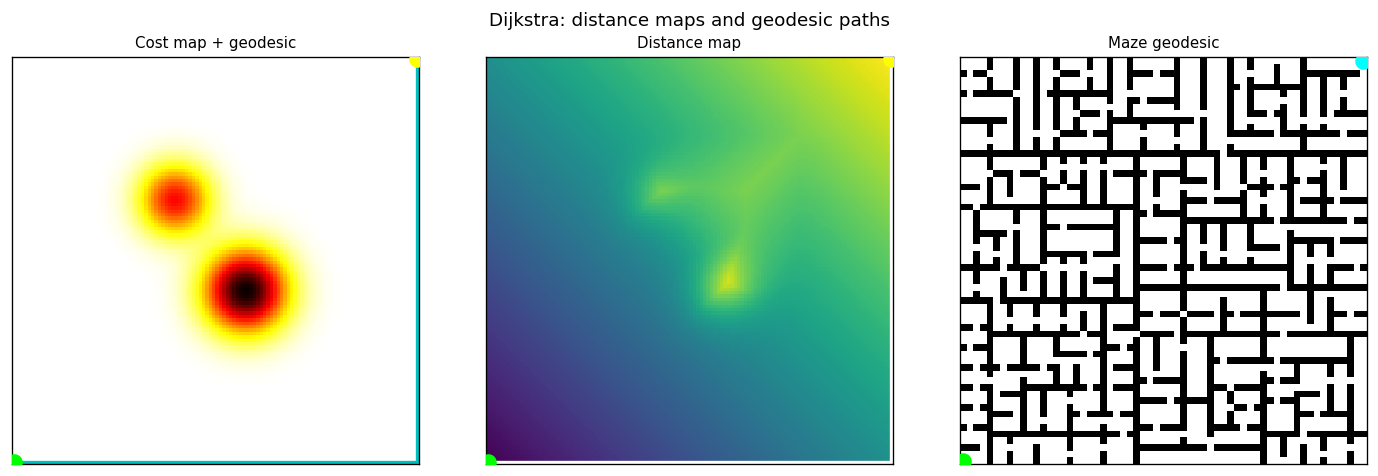

In [10]:
STATIC_SNAPSHOT = True

if STATIC_SNAPSHOT:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Panel 1: weight map + path
    ax = axes[0]
    ax.imshow(w_grid, origin="lower", cmap="hot_r", aspect="equal")
    if len(path_grid) > 0:
        ax.plot(path_grid[:, 1], path_grid[:, 0], "c-", lw=2)
    ax.scatter([0], [0], c="lime",   s=80, zorder=5)
    ax.scatter([n-1], [n-1], c="yellow", s=80, zorder=5)
    ax.set_title("Cost map + geodesic", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    # Panel 2: distance map
    ax = axes[1]
    ax.imshow(dist_grid, origin="lower", cmap="viridis", aspect="equal")
    if len(path_grid) > 0:
        ax.plot(path_grid[:, 1], path_grid[:, 0], "w-", lw=2)
    ax.scatter([0], [0], c="lime",   s=80, zorder=5)
    ax.scatter([n-1], [n-1], c="yellow", s=80, zorder=5)
    ax.set_title("Distance map", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    # Panel 3: maze + path
    ax = axes[2]
    ax.imshow(maze_binary, origin="lower", cmap="binary", aspect="equal",
              interpolation="nearest")
    if len(path_maze) > 0:
        ax.plot(path_maze[:, 1], path_maze[:, 0], "r-", lw=1.5)
    ax.scatter([0], [0],     c="lime", s=80, zorder=5)
    ax.scatter([nm-1], [nm-1], c="cyan", s=80, zorder=5)
    ax.set_title("Maze geodesic", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Dijkstra: distance maps and geodesic paths", fontsize=11)
    plt.tight_layout()
    fig.savefig(OUT / "snippet.png", bbox_inches="tight")

## Takeaways

- **Dijkstra's algorithm** efficiently solves single-source shortest paths on any graph with non-negative weights in $O((n+m)\log n)$ time via a priority queue.
- **Parent pointers** tracked during the algorithm allow exact geodesic path extraction by simple backtracking from any destination.
- On **weighted grids**, Dijkstra discretises the eikonal equation: the distance map $d(s, \cdot)$ encodes the travel time through a spatially-varying metric $w$.
- **Slow regions** (high-cost bumps) deflect the geodesic path, which detours around expensive areas — directly visible in the distance-map level sets.
- In **maze graphs** (binary free/wall weights), the algorithm reduces to a shortest-hop search through corridors, producing winding paths that reflect the maze topology.
- The interactive slider shows that moving the source causes a global reorganisation of the wavefronts, yet path extraction remains local and instantaneous.

## Bibliography

- Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik*, 1(1), 269–271.
- Cormen, T. H., Leiserson, C. E., Rivest, R. L. and Stein, C. (2009). *Introduction to Algorithms* (3rd ed.). MIT Press. Chapter 24.
- Sethian, J. A. (1996). A fast marching level set method for monotonically advancing fronts. *Proceedings of the National Academy of Sciences*, 93(4), 1591–1595.
- Kimmel, R. and Sethian, J. A. (1998). Computing geodesic paths on manifolds. *Proceedings of the National Academy of Sciences*, 95(15), 8431–8435.
- Peyré, G. and Cohen, L. D. (2006). Geodesic computations for fast and accurate surface remeshing and parameterization. *Elliptic and Parabolic Problems*, Birkhäuser, 157–171.